In [1]:
import pandas as pd
df = pd.read_csv('../../02_Data/processed/real_final_ml.csv')

In [2]:
df = df.drop(columns=['projectID'])

In [3]:
for col in df.columns:
    print(col)

enableBoardGameProperties
minPlayers
maxPlayers
minAge
playTime
fundedInSeconds
isDiscounted
previous_campaigns_count
duration_days
softclose
campaignGoal_usd_1m
fundsGathered_usd_1m
price_usd_1m
campaignGoal_usd_6m
fundsGathered_usd_6m
price_usd_6m
edge_density
saturation
brightness
contrast
rewards_count
R1
G1
B1
R2
G2
B2
R3
G3
B3
R4
G4
B4
ks_color_1
ks_color_2
ks_color_3
ks_color_4
emotion_adjective_1
emotion_adjective_2
emotion_adjective_3
emotion_adjective_4
creator_id_0
creator_id_1
is_pledge_master_0
is_pledge_master_1
is_backer_0
is_backer_1
is_prior_backer_0
is_prior_backer_1
is_pathfinder_0
is_pathfinder_1
is_normal_0
is_normal_1
likes_0
likes_1
Product_Question_count_0
Product_Question_count_1
Suggestion_Idea_count_0
Suggestion_Idea_count_1
Praise_Support_count_0
Praise_Support_count_1
Shipping_Fulfillment_count_0
Shipping_Fulfillment_count_1
Complaint_Refund_count_0
Complaint_Refund_count_1
Spam_Irrelevant_count_0
Spam_Irrelevant_count_1
긍정_0
긍정_1
부정_0
부정_1
중립_0
중립_1
Campai

In [4]:
# 성과 지표 y 
performance = [
    'campaignGoal_usd_1m', 'fundsGathered_usd_1m', 'price_usd_1m', 
    'campaignGoal_usd_6m', 'fundsGathered_usd_6m', 'price_usd_6m'
]

# 보드게임 기본 속성 / 'enableBoardGameProperties' 드랍
game_properties = [
    'minPlayers', 'maxPlayers', 'minAge', 'playTime'
]

# 캠페인 기본 정보   
campaign_info = [
    'isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose'
]

# 지역(화폐로)
location=[
    'currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 
    'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD'
    ]


# 사진 정보
image_features = [
    'edge_density', 'saturation', 'brightness', 'contrast'
]
# RGB
color_visual = [
    'R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4',
]
# 대표색
color_text = [
    'ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4'
]
# 대표 분위기
color_emotion = [
    'emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4'
]


# 댓글 정보     'is_backer_0', 'is_backer_1', 
comment_info = [
    'creator_id_0', 'creator_id_1', 
    'is_pledge_master_0', 'is_pledge_master_1',
    'is_prior_backer_0', 'is_prior_backer_1',
    'is_pathfinder_0', 'is_pathfinder_1', 
    'is_normal_0', 'is_normal_1', 
    'likes_0', 'likes_1'
]
# 댓글 3중분류(나라)
comment_3c = [
    '긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1'
]
# 댓글 3중분류(태연)
comment_topics = [
    'Campaign / Pledge_0', 'Campaign / Pledge_1', 
    'Community Reaction_0', 'Community Reaction_1',
    'Components & Production_0', 'Components & Production_1', 
    'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1',
    'Language & Localization_0', 'Language & Localization_1', 
    'Schedule / Updates_0', 'Schedule / Updates_1',
    'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1'
]
# 댓글 그룹(제미나이)
comment_j = [
    'Product_Question_count_0', 'Product_Question_count_1', 
    'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1',
    'Praise_Support_count_0', 'Praise_Support_count_1', 
    'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1',
    'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 
    'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1'
]


# 게임 장르 및 테마 태그
game_tags = [
    '4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 
    'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 
    'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 
    'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 
    'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 
    'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 
    'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 
    'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 
    'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday'
]


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

all_groups = {
    "game_properties": game_properties,
    "campaign_info": campaign_info,
    "location": location,
    "image_features": image_features,
    "color_visual": color_visual,
    "color_text": color_text,
    "color_emotion": color_emotion,
    "comment_info": comment_info, 
    "comment_3c": comment_3c,
    "comment_topics": comment_topics,
    "comment_j": comment_j,
    "game_tags": game_tags
}
# X 계속 바꾸며 test
active_groups = [
    "game_properties",
    "campaign_info",
    # "location",
    # image_features,
    "color_visual",
    # "color_text",
    # "color_emotion",
    # "comment_info",
    # "comment_3c",
    # "comment_topics",
    # "comment_j",
    # "game_tags"
]

selected_features = sum([all_groups[group] for group in active_groups], [])
features_desc = " + ".join(active_groups)


In [15]:
df['enableBoardGameProperties'].value_counts()

enableBoardGameProperties
1    471
0     12
Name: count, dtype: int64

In [16]:
'''
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

type_options = ["1m", "6m", "1m_ratio", "6m_ratio"]
log_options = [False, True]

for type_option in type_options:
    for log_option in log_options:
        
            
        if type_option == "1m":
            X = df[selected_features + ['campaignGoal_usd_1m', 'price_usd_1m']].copy()
            y = df['fundsGathered_usd_1m'].copy()
            if log_option: y = np.log1p(y)

        elif type_option == "6m":
            X = df[selected_features + ['campaignGoal_usd_6m', 'price_usd_6m']].copy()
            y = df['fundsGathered_usd_6m'].copy()
            if log_option: y = np.log1p(y)

        elif type_option == "1m_ratio":
            clean_df = df[df['price_usd_1m'] > 0].copy()
            X = clean_df[selected_features + ['campaignGoal_usd_1m']].copy()
            y = clean_df['fundsGathered_usd_1m'] / clean_df['price_usd_1m']

        elif type_option == "6m_ratio":
            clean_df = df[df['price_usd_6m'] > 0].copy()
            X = clean_df[selected_features + ['campaignGoal_usd_6m']].copy()
            y = clean_df['fundsGathered_usd_6m'] / clean_df['price_usd_6m']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )

        models = {
            "LinearRegression": LinearRegression(), 
            "Ridge": Ridge(),                      
            "Lasso": Lasso(),
            "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
            "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
            "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
        }

        model_results = []


        for name, model in models.items():
            model.fit(X_train, y_train)
            

            train_preds = model.predict(X_train)
            test_preds = model.predict(X_test)
            

            train_r2 = r2_score(y_train, train_preds)
            test_r2 = r2_score(y_test, test_preds)
            mae = mean_absolute_error(y_test, test_preds)

            gap = train_r2 - test_r2
            

            model_results.append({
                "Model": name,
                "Train_R2": round(train_r2, 4),
                "Test_R2": round(test_r2, 4),
                "Gap": round(gap, 4),
                "Test_MAE": round(mae, 4)
            })

        df_current_perf = pd.DataFrame(model_results).sort_values(by="Test_R2", ascending=False)


        print("=" * 60)
        print(f"• 타겟 옵션 : {type_option}")
        print(f"• 로그 변환 : {log_option if 'ratio' not in type_option else '정규화 불필요(비율)'}")
        print(f"• 사용 변수 : {features_desc}")
        print(f"• 변수 개수 : {len(X.columns)} 개")
        print("-" * 60)
        print(df_current_perf.to_string(index=False))
        print("=" * 60)
        print("\n" * 2)
'''

'\nimport numpy as np\nimport pandas as pd\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.linear_model import LinearRegression, Ridge, Lasso\nfrom sklearn.ensemble import RandomForestRegressor\nfrom lightgbm import LGBMRegressor\nfrom xgboost import XGBRegressor\nfrom sklearn.metrics import r2_score, mean_absolute_error\n\ntype_options = ["1m", "6m", "1m_ratio", "6m_ratio"]\nlog_options = [False, True]\n\nfor type_option in type_options:\n    for log_option in log_options:\n\n\n        if type_option == "1m":\n            X = df[selected_features + [\'campaignGoal_usd_1m\', \'price_usd_1m\']].copy()\n            y = df[\'fundsGathered_usd_1m\'].copy()\n            if log_option: y = np.log1p(y)\n\n        elif type_option == "6m":\n            X = df[selected_features + [\'campaignGoal_usd_6m\', \'price_usd_6m\']].copy()\n            y = df[\'fundsGathered_usd_6m\'].copy()\n            if log_option: y = np.log1p(y)\n\n        elif type_option == "1m_ratio":\n     

In [17]:
import itertools
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error

all_groups = {
    "game_properties": game_properties,
    "campaign_info": campaign_info,
    "location": location,
    "image_features" : image_features,
    "color_visual": color_visual,
    "color_text": color_text,
    "color_emotion": color_emotion,
    "comment_info": comment_info, 
    "comment_3c": comment_3c,
    "comment_topics": comment_topics,
    "comment_j": comment_j,
    "game_tags": game_tags
}

fixed_groups = ["game_properties", "campaign_info"]
candidate_groups = [
    "location","image_features", "color_visual", "color_text", "color_emotion",
    "comment_info", "comment_3c", "comment_topics", "comment_j", "game_tags"
]

master_results = []

# 🌟 [속도 최적화] train_test_split을 루프 밖으로 이동
# 데이터프레임을 미리 쪼개어 두어 512번의 반복 분할 연산을 방지합니다.
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, shuffle=True
)

# 2. 후보 그룹들로 만들 수 있는 모든 조합 루프 생성 (0개 추가 ~ 9개 모두 추가)
for r in range(len(candidate_groups) + 1):
    for combo in itertools.combinations(candidate_groups, r):
        
        # 현재 루프에서 사용할 최종 active_groups 구성
        active_groups = fixed_groups + list(combo)
        features_desc = " + ".join(active_groups)
        added_desc = ", ".join(combo) if combo else "None (기본형)"
        
        # 피처 리스트 취합
        selected_features = sum([all_groups[group] for group in active_groups], [])
        final_features = selected_features + ['campaignGoal_usd_1m', 'price_usd_1m']
        
        # 🌟 [속도 최적화] 분할된 데이터셋에서 필요한 컬럼만 슬라이싱(Copy)하여 사용
        X_train = df_train[final_features].copy()
        X_test = df_test[final_features].copy()
        
        y_train = np.log1p(df_train['fundsGathered_usd_1m'])
        y_test = np.log1p(df_test['fundsGathered_usd_1m'])

        # 평가할 모델 정의
        models = {
            "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
            "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
            "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
        }

        # 모델 학습 및 결과 수집
        for name, model in models.items():
            model.fit(X_train, y_train)
            
            train_preds = model.predict(X_train)
            test_preds = model.predict(X_test)
            
            train_r2 = r2_score(y_train, train_preds)
            test_r2 = r2_score(y_test, test_preds)
            gap = train_r2 - test_r2
            
            # 단위 복원
            true_y_test = np.expm1(y_test)
            true_test_preds = np.expm1(test_preds)
            
            # 복원된 오차
            real_mae = mean_absolute_error(true_y_test, true_test_preds)
            real_med_ae = median_absolute_error(true_y_test, true_test_preds)
            
            master_results.append({
                "Added_Groups": added_desc,
                "Model": name,
                "Train_R2": round(train_r2, 4),
                "Test_R2": round(test_r2, 4),
                "Gap": round(gap, 4),
                "Test_MAE_Real": round(real_mae, 2),       
                "Test_med_MAE_Real": round(real_med_ae, 2), 
                "Feature_Count": len(X_train.columns) # 🌟 X_train 기준 개수로 변경
            })

df_all_combos = pd.DataFrame(master_results)

# 오차 중앙값 기준 오름차순 정렬 (가장 잘 맞춘 모델이 위로)
df_top15 = df_all_combos.sort_values(by="Test_med_MAE_Real", ascending=True).head(15)

print("=" * 90)
print("🏆 최적의 변수 조합 및 모델 TOP 15 결과 (원래 단위 오차 복원 버전) 🏆")
print("-" * 90)
print(df_top15.to_string(index=False))
print("=" * 90)

🏆 최적의 변수 조합 및 모델 TOP 15 결과 (원래 단위 오차 복원 버전) 🏆
------------------------------------------------------------------------------------------
                                                                            Added_Groups    Model  Train_R2  Test_R2    Gap  Test_MAE_Real  Test_med_MAE_Real  Feature_Count
                location, image_features, color_text, comment_info, comment_j, game_tags  XGBoost    1.0000   0.9290 0.0710      128905.71            3858.13            115
                          image_features, color_text, comment_info, comment_j, game_tags  XGBoost    1.0000   0.9280 0.0720      125203.30            4022.99            109
                                                                color_text, comment_info  XGBoost    1.0000   0.9237 0.0763      133717.04            4303.97             30
                                     image_features, color_text, comment_info, comment_j  XGBoost    1.0000   0.9385 0.0615      130746.02            4305.79             4

In [ ]:
# 옵투나
'''
import numpy as np
import pandas as pd
import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split # 🌟 데이터 분할을 위한 라이브러리
from sklearn.metrics import median_absolute_error, r2_score

# ====================================================================
# 0. 데이터 분할 정의 (여기서 df_train과 df_test가 만들어집니다!)
# ====================================================================
# 원본 데이터프레임인 'df'를 가지고 계신 상태에서 아래 줄을 실행하면 됩니다.
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


# 1. 11번째 줄의 베스트 변수 조합 딱 하나만 고정!
best_group = ["game_properties", "campaign_info", "color_text", "comment_info", "comment_3c"]
selected_features = sum([all_groups[group] for group in best_group], [])
final_features = selected_features + ['campaignGoal_usd_1m', 'price_usd_1m']

# 데이터 세팅 (방금 위에서 정의한 df_train, df_test를 사용합니다)
X_train = df_train[final_features].copy()
X_test = df_test[final_features].copy()
y_train = np.log1p(df_train['fundsGathered_usd_1m'])
y_test = np.log1p(df_test['fundsGathered_usd_1m'])

# 2. Optuna 목적 함수 정의
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }
    
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    
    # 예측 및 원래 단위 복원
    test_preds = model.predict(X_test)
    true_y_test = np.expm1(y_test)
    true_test_preds = np.expm1(test_preds)
    
    # 우리가 타겟으로 삼을 오차 지표 계산
    test_med_ae = median_absolute_error(true_y_test, true_test_preds)
    
    # 모니터링용 R2 저장
    train_preds = model.predict(X_train)
    trial.set_user_attr("Test_R2", r2_score(y_test, test_preds))
    trial.set_user_attr("Gap", r2_score(y_train, train_preds) - r2_score(y_test, test_preds))
    
    return test_med_ae # 오차 중앙값 최소화가 목표!

# 3. 튜닝 시작
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

# 4. 최적의 결과 확인
print("=" * 60)
print(f"🏆 Optuna 정밀 튜닝 완료 🏆")
print(f"• 최적의 파라미터로 줄인 중앙값 오차: {round(study.best_value, 2)} 달러")
print(f"• 그때의 Test_R2 점수: {round(study.best_trial.user_attrs['Test_R2'], 4)}")
print(f"• 그때의 과적합 격차(Gap): {round(study.best_trial.user_attrs['Gap'], 4)}")
print(f"• 추천 하이퍼파라미터: \n{study.best_params}")
print("=" * 60)
'''

[I 2026-06-11 19:01:23,588] A new study created in memory with name: no-name-2c0877a0-70c2-4075-a63f-34856f2713ff
[I 2026-06-11 19:01:23,673] Trial 0 finished with value: 5983.885235938156 and parameters: {'max_depth': 3, 'learning_rate': 0.06018919480205503, 'n_estimators': 149, 'min_child_samples': 13, 'subsample': 0.6387697251895071}. Best is trial 0 with value: 5983.885235938156.
[I 2026-06-11 19:01:23,845] Trial 1 finished with value: 8681.941394047015 and parameters: {'max_depth': 8, 'learning_rate': 0.07519946592338939, 'n_estimators': 410, 'min_child_samples': 29, 'subsample': 0.6794285339982143}. Best is trial 0 with value: 5983.885235938156.
[I 2026-06-11 19:01:23,914] Trial 2 finished with value: 8989.58860017424 and parameters: {'max_depth': 7, 'learning_rate': 0.08174248467056278, 'n_estimators': 314, 'min_child_samples': 36, 'subsample': 0.9048940807842288}. Best is trial 0 with value: 5983.885235938156.
[I 2026-06-11 19:01:23,992] Trial 3 finished with value: 10306.87947

🏆 Optuna 정밀 튜닝 완료 🏆
• 최적의 파라미터로 줄인 중앙값 오차: 4929.26 달러
• 그때의 Test_R2 점수: 0.9244
• 그때의 과적합 격차(Gap): 0.0409
• 추천 하이퍼파라미터: 
{'max_depth': 5, 'learning_rate': 0.08721028206513479, 'n_estimators': 100, 'min_child_samples': 26, 'subsample': 0.9619498358600842}


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error



baseline_features = game_properties + campaign_info + location
# 통제 변수 추가 (목표 금액과 기본 가격은 출시 시점에 알 수 있는 기본 스펙입니다)
control_features = ['campaignGoal_usd_1m', 'price_usd_1m']
final_baseline_X = baseline_features + control_features

# 데이터 세팅
X_stage1 = df[final_baseline_X].copy()
y_stage1 = df['fundsGathered_usd_1m'].copy()

# 타겟 변수 로그화
y_stage1_log = np.log1p(y_stage1)

# ====================================================================
# 2. 데이터 분할 (Train / Test 8:2)
# ====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_stage1, y_stage1_log, test_size=0.2, random_state=42, shuffle=True
)

# ====================================================================
# 3. Baseline 모델 평가할 라인업 정의
# ====================================================================
models = {
    "RandomForest": RandomForestRegressor(max_depth=8, random_state=42, n_jobs=-1), # 과적합 방지용 max_depth 제한
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1)
}

stage1_results = []

# 모델 학습 및 검증 루프
for name, model in models.items():
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측값 도출 (로그 스케일 상태)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # R2 및 Gap 계산 (패턴 설명력 측정)
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    gap = train_r2 - test_r2
    
    # 원래 단위(달러)로 복원
    true_y_test = np.expm1(y_test)
    true_test_preds = np.expm1(test_preds)
    
    # 복원된 진짜 오차 계산
    real_mae = mean_absolute_error(true_y_test, true_test_preds)
    real_med_ae = median_absolute_error(true_y_test, true_test_preds)
    
    # 결과 수집
    stage1_results.append({
        "Model": name,
        "Train_R2": round(train_r2, 4),
        "Test_R2": round(test_r2, 4),
        "Gap": round(gap, 4),
        "Test_MAE_Real": round(real_mae, 2),
        "Test_med_MAE_Real": round(real_med_ae, 2),
        "Feature_Count": len(X_stage1.columns)
    })

# ====================================================================
# 4. Stage 1 최종 결과 출력
# ====================================================================
df_stage1_metrics = pd.DataFrame(stage1_results)

print("=" * 80)
print("📊 [Stage 1: Baseline] 보드게임/캠페인 기본 정보 예측 결과 📊")
print("-" * 80)
print(df_stage1_metrics.to_string(index=False))
print("=" * 80)

📊 [Stage 1: Baseline] 보드게임/캠페인 기본 정보 예측 결과 📊
--------------------------------------------------------------------------------
       Model  Train_R2  Test_R2    Gap  Test_MAE_Real  Test_med_MAE_Real  Feature_Count
RandomForest    0.9766   0.8822 0.0944      134681.62            7456.94             18
    LightGBM    0.9637   0.8462 0.1174      149204.01            7641.49             18
     XGBoost    1.0000   0.8261 0.1738      152972.58            6076.13             18


In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error

stage2_results = []

# Stage 1에서 검증했던 기본 베이스라인 피처 셋팅
base_features = game_properties + campaign_info + location + ['campaignGoal_usd_1m', 'price_usd_1m']

# ====================================================================
# 1. 3가지 컨셉트 시나리오 피처 그룹 정의
# ====================================================================
scenarios = {
    # 시나리오 A: 기계가 읽는 단순 물리적 수치 (Raw RGB 및 사진 통계)
    "Stage 2-A (Physical)": base_features + image_features + color_visual,
    
    # 시나리오 B: 인간이 느끼는 심리적 의미 (대표 색상 감정 형용사)
    "Stage 2-B (Semantic)": base_features + color_text + color_emotion,
    
    # 시나리오 C: 시각 정보 전체 투입 (물리 + 심리 올인)
    "Stage 2-C (All-In)": base_features + image_features + color_visual + color_text + color_emotion
}

# 평가할 핵심 모델 라인업 (Stage 1과 동일한 하이퍼파라미터 유지)
models = {
    "RandomForest": RandomForestRegressor(max_depth=8, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1)
}

# ====================================================================
# 2. 시나리오별 모델 학습 및 검증 루프 구동
# ====================================================================
for scenario_name, feature_list in scenarios.items():
    
    # 데이터셋 준비
    X_scen = df[feature_list].copy()
    y_scen = np.log1p(df['fundsGathered_usd_1m'])
    
    # 동일한 기준으로 Train / Test 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X_scen, y_scen, test_size=0.2, random_state=42, shuffle=True
    )
    
    for model_name, model in models.items():
        # 모델 학습
        model.fit(X_train, y_train)
        
        # 예측값 도출
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)
        
        # 지표 계산
        train_r2 = r2_score(y_train, train_preds)
        test_r2 = r2_score(y_test, test_preds)
        gap = train_r2 - test_r2
        
        # 원래 단위(달러) 복원 후 진짜 오차 계산
        true_y_test = np.expm1(y_test)
        true_test_preds = np.expm1(test_preds)
        real_mae = mean_absolute_error(true_y_test, true_test_preds)
        real_med_ae = median_absolute_error(true_y_test, true_test_preds)
        
        # 결과 마스터 리스트에 누적
        stage2_results.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "Train_R2": round(train_r2, 4),
            "Test_R2": round(test_r2, 4),
            "Gap": round(gap, 4),
            "Test_MAE_Real": round(real_mae, 2),
            "Test_med_MAE_Real": round(real_med_ae, 2),
            "Feature_Count": len(X_scen.columns)
        })

# ====================================================================
# 3. 실험 결과 테이블 출력
# ====================================================================
df_stage2_metrics = pd.DataFrame(stage2_results)

print("=" * 80)
print("🏆 [Stage 2 결과] 물리 수치(A) vs 심리 인지(B) vs 전체 투입(C) 정면 비교 🏆")
print("-" * 80)
print(df_stage2_metrics.to_string(index=False))
print("=" * 80)

🏆 [Stage 2 결과] 물리 수치(A) vs 심리 인지(B) vs 전체 투입(C) 정면 비교 🏆
--------------------------------------------------------------------------------
            Scenario        Model  Train_R2  Test_R2    Gap  Test_MAE_Real  Test_med_MAE_Real  Feature_Count
Stage 2-A (Physical) RandomForest    0.9762   0.8785 0.0977      155174.10            7011.10             34
Stage 2-A (Physical)     LightGBM    0.9841   0.8418 0.1424      156325.08            5318.64             34
Stage 2-A (Physical)      XGBoost    1.0000   0.8614 0.1386      181573.55            7656.70             34
Stage 2-B (Semantic) RandomForest    0.9767   0.8810 0.0956      134751.04            8012.57             26
Stage 2-B (Semantic)     LightGBM    0.9735   0.8304 0.1431      158990.97            5380.53             26
Stage 2-B (Semantic)      XGBoost    1.0000   0.8168 0.1832      143527.12            6130.52             26
  Stage 2-C (All-In) RandomForest    0.9761   0.8763 0.0999      148615.88            7250.21       

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error

stage3_results = []

# [Stage 2-B] 승자 조합을 기본 베이스 피처로 지정
stage2_best_features = game_properties + campaign_info + location + ['campaignGoal_usd_1m', 'price_usd_1m'] + color_text + color_emotion

# ====================================================================
# 1. 3가지 댓글 시나리오 피처 그룹 정의
# ====================================================================
scenarios_stage3 = {
    # 시나리오 A: 댓글 작성자 성향 및 기본 인게이지먼트
    "Stage 3-A (Engagement)": stage2_best_features + comment_info,
    
    # 시나리오 B: 전통적 텍스트 마이닝 (주제 키워드 및 기본 긍부정)
    "Stage 3-B (Topic & Sent)": stage2_best_features + comment_topics + comment_3c,
    
    # 시나리오 C: 최신 LLM(Gemini) 기반 유저 행동 의도 분류
    "Stage 3-C (Gemini Intent)": stage2_best_features + comment_j
}

# 평가할 모델 라인업 (동일 조건 유지)
models = {
    "RandomForest": RandomForestRegressor(max_depth=8, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1)
}

# ====================================================================
# 2. 시나리오별 모델 학습 및 검증 루프 구동
# ====================================================================
for scenario_name, feature_list in scenarios_stage3.items():
    
    X_scen = df[feature_list].copy()
    y_scen = np.log1p(df['fundsGathered_usd_1m'])
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scen, y_scen, test_size=0.2, random_state=42, shuffle=True
    )
    
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)
        
        train_r2 = r2_score(y_train, train_preds)
        test_r2 = r2_score(y_test, test_preds)
        gap = train_r2 - test_r2
        
        true_y_test = np.expm1(y_test)
        true_test_preds = np.expm1(test_preds)
        real_mae = mean_absolute_error(true_y_test, true_test_preds)
        real_med_ae = median_absolute_error(true_y_test, true_test_preds)
        
        stage3_results.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "Train_R2": round(train_r2, 4),
            "Test_R2": round(test_r2, 4),
            "Gap": round(gap, 4),
            "Test_MAE_Real": round(real_mae, 2),
            "Test_med_MAE_Real": round(real_med_ae, 2),
            "Feature_Count": len(X_scen.columns)
        })

# ====================================================================
# 3. 실험 결과 테이블 출력
# ====================================================================
df_stage3_metrics = pd.DataFrame(stage3_results)

print("=" * 110)
print("🏆 [Stage 3 결과] 인게이지먼트(A) vs 주제/감성(B) vs 제미나이 의도분류(C) 비교 🏆")
print("-" * 110)
print(df_stage3_metrics.to_string(index=False))
print("=" * 110)

🏆 [Stage 3 결과] 인게이지먼트(A) vs 주제/감성(B) vs 제미나이 의도분류(C) 비교 🏆
--------------------------------------------------------------------------------------------------------------
                 Scenario        Model  Train_R2  Test_R2    Gap  Test_MAE_Real  Test_med_MAE_Real  Feature_Count
   Stage 3-A (Engagement) RandomForest    0.9781   0.9141 0.0640      100896.44            8525.19             38
   Stage 3-A (Engagement)     LightGBM    0.9808   0.8990 0.0818      147577.38           10145.55             38
   Stage 3-A (Engagement)      XGBoost    1.0000   0.9070 0.0930      116634.32            5410.12             38
 Stage 3-B (Topic & Sent) RandomForest    0.9773   0.8828 0.0945      109825.81           10195.07             46
 Stage 3-B (Topic & Sent)     LightGBM    0.9821   0.8855 0.0965      145163.63            8659.70             46
 Stage 3-B (Topic & Sent)      XGBoost    1.0000   0.8793 0.1207      102716.14            8323.27             46
Stage 3-C (Gemini Intent) RandomF

In [ ]:
--------------------------------------------------------------------------------------------------------------
           Model  Train_R2  Test_R2    Gap      Test_MAE  Test_med_MAE  Feature_Count
3-A RandomForest    0.9781  0.9141   0.0640    100896.44    8525.19          38
3-A     LightGBM    0.9808  0.8990   0.0818    147577.38   10145.55          38
3-A      XGBoost    1.0000  0.9070   0.0930    116634.32    5410.12          38
3-B RandomForest    0.9773  0.8828   0.0945    109825.81   10195.07          46
3-B     LightGBM    0.9821  0.8855   0.0965    145163.63    8659.70          46
3-B      XGBoost    1.0000  0.8793   0.1207    102716.14    8323.27          46
3-C  RandomForest   0.9774  0.9080   0.0693     92436.32    8646.81          38
3-C      LightGBM   0.9786  0.8933   0.0853    107130.80    9050.00          38
3-C       XGBoost   1.0000  0.8992   0.1008    111156.35    9884.34          38
==============================================================================================================

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error

# ====================================================================
# 1. Stage 3-A 승자 조합 + 최종 game_tags 피처 결합
# ====================================================================
# [!] 상단에 개별 리스트들이 모두 선언되어 있어야 합니다.
stage3_best_features = (
    game_properties + campaign_info + location + 
    ['campaignGoal_usd_1m', 'price_usd_1m'] + 
    color_text + color_emotion + 
    comment_info
)

# 최종 챔피언십 투입 피처 셋팅
final_champion_features = stage3_best_features + game_tags

X_stage4 = df[final_champion_features].copy()
y_stage4 = np.log1p(df['fundsGathered_usd_1m'])

# 동일한 데이터 분할 구조 유지
X_train, X_test, y_train, y_test = train_test_split(
    X_stage4, y_stage4, test_size=0.2, random_state=42, shuffle=True
)

# 평가할 모델 라인업 (최종 라운드)
models = {
    "RandomForest": RandomForestRegressor(max_depth=8, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1)
}

stage4_results = []

# 모델 학습 및 검증
for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    gap = train_r2 - test_r2
    
    # 진짜 스케일 복원
    true_y_test = np.expm1(y_test)
    true_test_preds = np.expm1(test_preds)
    real_mae = mean_absolute_error(true_y_test, true_test_preds)
    real_med_ae = median_absolute_error(true_y_test, true_test_preds)
    
    stage4_results.append({
        "Model": name,
        "Train_R2": round(train_r2, 4),
        "Test_R2": round(test_r2, 4),
        "Gap": round(gap, 4),
        "Test_MAE_Real": round(real_mae, 2),
        "Test_med_MAE_Real": round(real_med_ae, 2),
        "Feature_Count": len(X_stage4.columns)
    })

# ====================================================================
# 2. Stage 4 최종 결과 출력
# ====================================================================
df_stage4_metrics = pd.DataFrame(stage4_results)

print("=" * 100)
print("🏆 [Stage 4 결과] 최종 장르 및 테마 태그 투입 후 마스터 성적표 🏆")
print("-" * 100)
print(df_stage4_metrics.to_string(index=False))
print("=" * 100)

🏆 [Stage 4 결과] 최종 장르 및 테마 태그 투입 후 마스터 성적표 🏆
----------------------------------------------------------------------------------------------------
       Model  Train_R2  Test_R2    Gap  Test_MAE_Real  Test_med_MAE_Real  Feature_Count
RandomForest    0.9782   0.9111 0.0671      104332.87            7739.89            101
    LightGBM    0.9823   0.8963 0.0859      150877.14            5723.48            101
     XGBoost    1.0000   0.9051 0.0949      109585.55            6286.68            101


C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_15400\3034091659.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_15400\3034091659.py:22: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\NT551_11TH\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


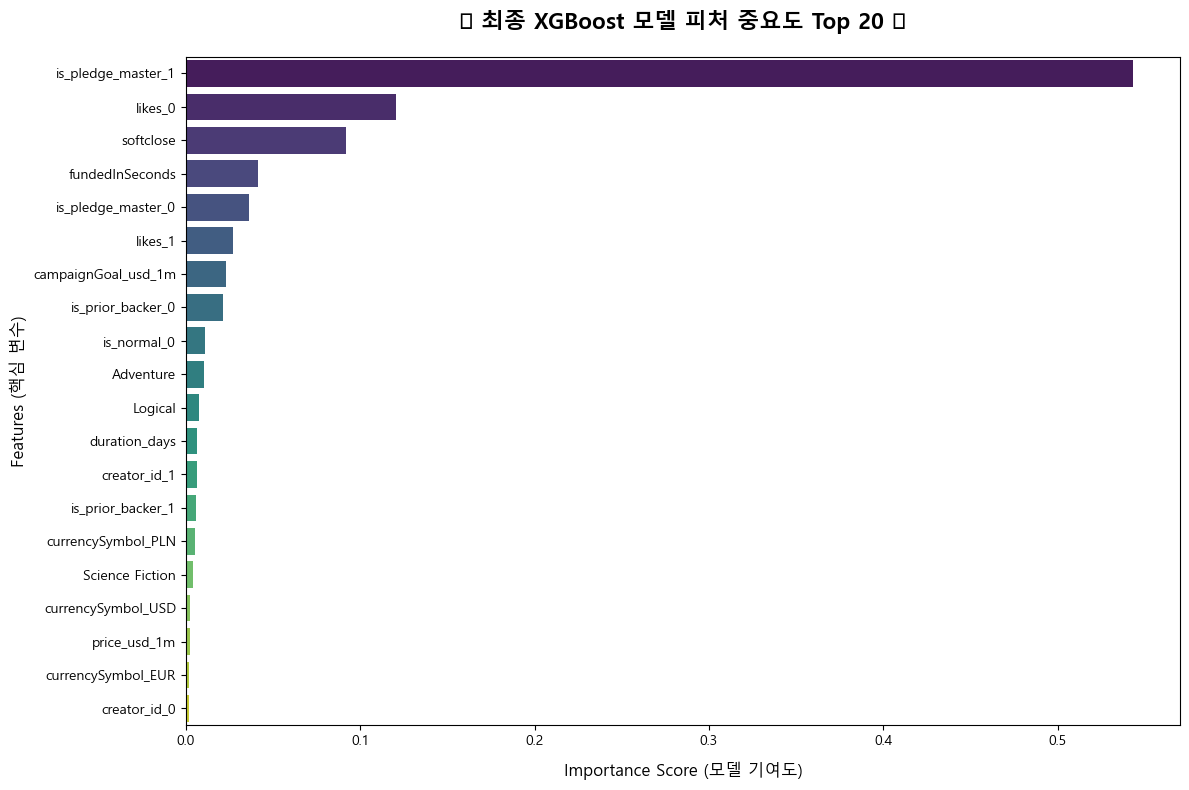

🎯 [수치 증거] 데이터 탑 20 변수 리스트
--------------------------------------------------
            Feature  Importance
 is_pledge_master_1    0.543115
            likes_0    0.120288
          softclose    0.092120
    fundedInSeconds    0.041606
 is_pledge_master_0    0.036196
            likes_1    0.027082
campaignGoal_usd_1m    0.023168
  is_prior_backer_0    0.021020
        is_normal_0    0.011173
          Adventure    0.010227
            Logical    0.007743
      duration_days    0.006621
       creator_id_1    0.006342
  is_prior_backer_1    0.005629
 currencySymbol_PLN    0.005002
    Science Fiction    0.003843
 currencySymbol_USD    0.002566
       price_usd_1m    0.002167
 currencySymbol_EUR    0.001878
       creator_id_0    0.001849


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 윈도우 환경 한글 깨짐 방지 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 2. 현재 메모리에 저장된 마지막 모델(XGBoost)의 피처 중요도 추출
df_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. 포트폴리오 박아넣기용 상위 20개 핵심 변수 시각화
plt.figure(figsize=(12, 8))
# 눈이 편안하면서도 프로페셔널해 보이는 viridis 색상 맵 적용
sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis') 

plt.title('🏆 최종 XGBoost 모델 피처 중요도 Top 20 🏆', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score (모델 기여도)', fontsize=12, labelpad=10)
plt.ylabel('Features (핵심 변수)', fontsize=12)
plt.tight_layout()
plt.show()

# 4. 상위 20개 텍스트 수치로도 확인하기
print("=" * 50)
print("🎯 [수치 증거] 데이터 탑 20 변수 리스트")
print("-" * 50)
print(df_importance.head(20).to_string(index=False))
print("=" * 50)